# Modelagem

Nesse notebook iremos testar diversas abordagens de modelagem e iremos escolher a que performar melhor no nosso dataset.

## Importando as Bibliotecas

Primeiro, vamos importar nossas bibliotecas.

In [68]:
import numpy as np
import pandas as pd

## Carregando o Dataset

Agora, vamos carregar o dataset.

In [69]:
df = pd.read_parquet("../data/processed/03_processed.parquet")

In [70]:
df = df.astype("float").reset_index()

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 84 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   index                        7253 non-null   int64  
 1   preco                        7253 non-null   float64
 2   condominio                   5627 non-null   float64
 3   iptu                         4258 non-null   float64
 4   tamanho                      7253 non-null   float64
 5   quartos                      7252 non-null   float64
 6   banheiros                    7252 non-null   float64
 7   vagas_estacionamento         7051 non-null   float64
 8   andar                        3262 non-null   float64
 9   piscina                      7253 non-null   float64
 10  elevador                     7253 non-null   float64
 11  churrasqueira                7253 non-null   float64
 12  condominio_fechado           7253 non-null   float64
 13  academia                     

## Divisão Treino-Teste

Nessa etapa de modelagem faremos otimização de hiperparâmetros dos nossos modelos e para checarmos a qualidade final do modelo iremos testâ-lo em dados de teste. Para isso precisamos dividir os dados de treinamento e de teste.

In [105]:
from sklearn.model_selection import train_test_split

X = df.drop("preco", axis="columns").values
y = df["preco"].values

random_state = 1668

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=random_state,
)

## Regressão Linear com Regularização L1 (Lasso)

O primeiro modelo que iremos treinar é o modelo de Regressão Linear com Regularização L1, também conhecida como Lasso, sendo esse modelo o nosso baseline. Faremos a otimização de hiperparâmetros desse modelo usando a Validação Cruzada com 5 folds e usando a biblioteca `Optuna`.

In [108]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import (
    KFold,
    cross_val_score,
    cross_validate,
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline


kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state,
)

def get_elastic_net_pipeline(parameters):
    imputer = SimpleImputer(
        strategy="median"
    )

    scaler = StandardScaler()
    
    model = ElasticNet(
        alpha=parameters["alpha"],
        l1_ratio=parameters["l1_ratio"],
        max_iter=5000,
        random_state=random_state,
    )

    pipeline = Pipeline(steps=[
        ("imputer", imputer),
        ("scaler", scaler),
        ("model", model),
    ])

    return pipeline


def objective_elastic_net(trial):
    pipeline = get_elastic_net_pipeline({
        "n_neighbors": trial.suggest_int("n_neighbors", 1, 20),
        "alpha": trial.suggest_float("alpha", 1e-6, 10.0, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
    })

    scores = cross_val_score(
        pipeline,
        X_train,
        np.log1p(y_train),
        cv=kfold,
        scoring="r2",
    )

    return scores.mean()

Agora que montamos nossa função objetivo, vamos criar nosso estudo e executar a otimização de hiperparâmetros.

In [109]:
import optuna

study = optuna.create_study(
    direction="maximize",
)

study.optimize(
    objective_elastic_net,
    n_trials=20,
    show_progress_bar=True,
)

[I 2026-08-03 03:43:33,108] A new study created in memory with name: no-name-f444da94-f985-4702-9bd5-47bfcaa1fe0e
Best trial: 0. Best value: 0.538674:   5%|▌         | 1/20 [00:00<00:03,  5.28it/s]

[I 2026-08-03 03:43:33,293] Trial 0 finished with value: 0.538673988862725 and parameters: {'n_neighbors': 14, 'alpha': 0.059362923970897645, 'l1_ratio': 0.44502351520888206}. Best is trial 0 with value: 0.538673988862725.


Best trial: 1. Best value: 0.600679:  15%|█▌        | 3/20 [00:00<00:04,  4.14it/s]

[I 2026-08-03 03:43:33,702] Trial 1 finished with value: 0.6006790341707301 and parameters: {'n_neighbors': 5, 'alpha': 0.003196761260691092, 'l1_ratio': 0.20338029047092376}. Best is trial 1 with value: 0.6006790341707301.
[I 2026-08-03 03:43:33,855] Trial 2 finished with value: 0.46386597539794716 and parameters: {'n_neighbors': 3, 'alpha': 0.2612594035542486, 'l1_ratio': 0.6572103374949873}. Best is trial 1 with value: 0.6006790341707301.


Best trial: 3. Best value: 0.609816:  20%|██        | 4/20 [00:01<00:06,  2.44it/s]

...

[I 2026-08-03 03:43:47,889] Trial 17 finished with value: 0.6129163378456577 and parameters: {'n_neighbors': 8, 'alpha': 1.1191249249072267e-06, 'l1_ratio': 0.1395782198741729}. Best is trial 12 with value: 0.6129201883256563.


Best trial: 12. Best value: 0.61292:  95%|█████████▌| 19/20 [00:15<00:01,  1.22s/it]

[I 2026-08-03 03:43:48,929] Trial 18 finished with value: 0.6124527380685958 and parameters: {'n_neighbors': 13, 'alpha': 8.486308301350483e-05, 'l1_ratio': 0.11983112691652803}. Best is trial 12 with value: 0.6129201883256563.


Best trial: 12. Best value: 0.61292: 100%|██████████| 20/20 [00:17<00:00,  1.18it/s]

[I 2026-08-03 03:43:50,123] Trial 19 finished with value: 0.6128556720125644 and parameters: {'n_neighbors': 3, 'alpha': 6.373553329874442e-06, 'l1_ratio': 0.33080111022415987}. Best is trial 12 with value: 0.6129201883256563.


In [110]:
print(f"Best R^2: {study.best_value}")

Best R^2: 0.6129201883256563


In [111]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
)

pipeline = get_elastic_net_pipeline({'n_neighbors': 9, 'alpha': 0.00012013874253855576, 'l1_ratio': 0.4469230813017634})

pipeline.fit(X_train, np.log1p(y_train))
y_pred = pipeline.predict(X_test)

print("========== Lasso Metrics ==========")
print(f"R^2:  {r2_score(np.log1p(y_test), y_pred)}")
print(f"MAE:  {mean_absolute_error(np.log1p(y_test), y_pred)}")
print(f"RMSE: {root_mean_squared_error(np.log1p(y_test), y_pred)}")

========== Lasso Metrics ==========
R^2:  0.8204215159515759
MAE:  0.20576081582188852
RMSE: 0.2735574040001435


In [112]:
(np.log1p(y_test) - y_pred).mean()

np.float64(0.0072004894847054945)

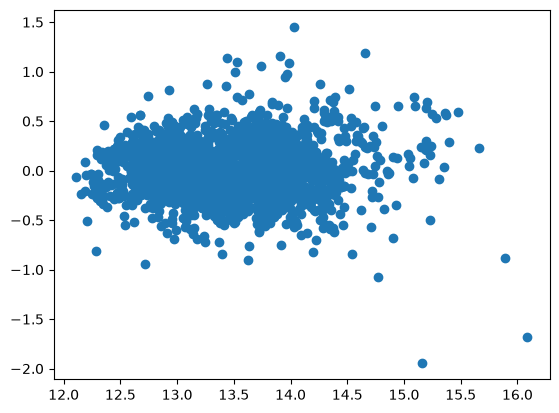

In [113]:
import matplotlib.pyplot as plt

plt.scatter(x=y_pred, y=(np.log1p(y_test) - y_pred))
plt.show()

(array([2.175e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

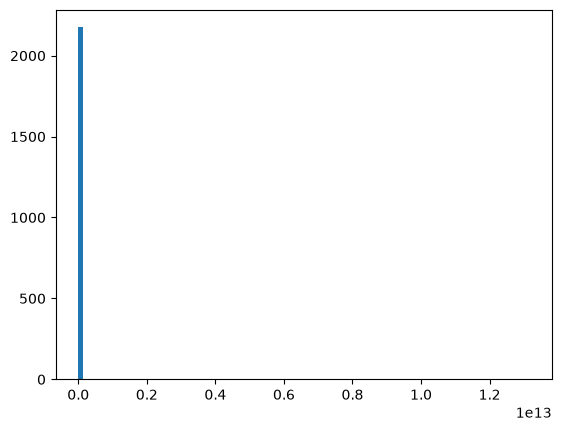

In [94]:
plt.hist(y_pred, bins=100)

(array([  1.,  47., 112., 278., 271., 256., 223., 143., 113., 134.,  70.,
         74.,  68.,  67.,  24.,  46.,  39.,  34.,  28.,  25.,  14.,  10.,
          6.,   6.,   6.,   2.,   5.,   0.,   6.,   7.,   5.,   8.,   2.,
          4.,   8.,   0.,   7.,   0.,   1.,   3.,   1.,   2.,   0.,   1.,
          1.,   0.,   0.,   0.,   0.,   1.,   3.,   1.,   0.,   2.,   0.,
          1.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   2.,   0.,   0.,   0.,   0.,   1.,   1.,   0.,   0.,   1.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([  25000.,  119750.,  214500.,  309250.,  404000.,  498750.,
         593500.,  688250.,  783000.,  877750.,  972500., 1067250.,
        1162000., 1256750., 1351500., 1446250., 1541000., 1635750.,
        1730500., 1825250., 1920000., 2014750., 2109500., 2204250.,
        2299000., 2393750., 2488500., 2583250.

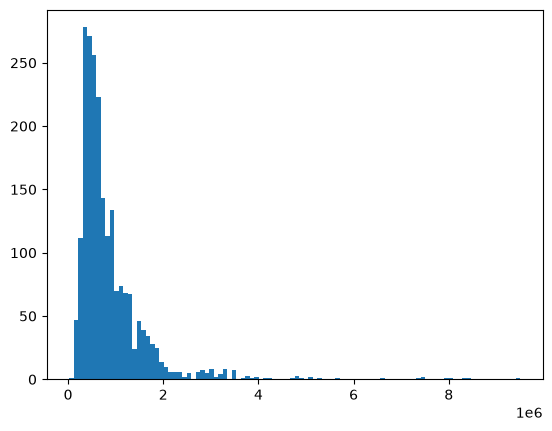

In [95]:
plt.hist(y_test, bins=100)

In [1]:
pipeline.named_steps["model"].coef_

NameError: name 'pipeline' is not defined